# Loading the Libraries and Data

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [33]:
data = pd.read_csv('IPL.csv')
data.head()


,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


## Basic Information

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [35]:
print(f"The data has {data.shape[0]} rows and {data.shape[1]} columns")

The data has 74 rows and 20 columns


### Check if the data has null values.

In [36]:
data.isnull().sum() #There is no null values in data.

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


## Which team won the most matches?

In [37]:
most_match_win = data.match_winner.value_counts()
most_match_win

,count
match_winner,
Gujarat,12
Rajasthan,10
Banglore,9
Lucknow,9
Punjab,7
Delhi,7
Kolkata,6
Hyderabad,6
Chennai,4


### For better understand let's make a bar plot...

Text(0.5, 1.0, 'Most Matches Won By Teams')

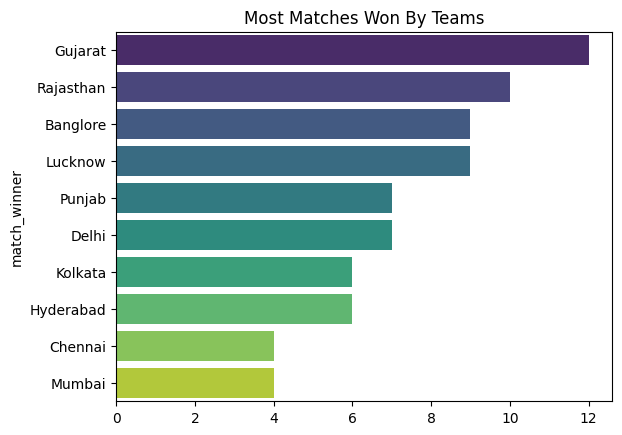

In [38]:
sns.barplot(y = most_match_win.index,x = most_match_win.values,palette='viridis')
plt.title('Most Matches Won By Teams')


## Toss decision Trend

In [39]:
data.toss_decision.value_counts()

,count
toss_decision,
Field,59
Bat,15


<Axes: xlabel='toss_decision', ylabel='count'>

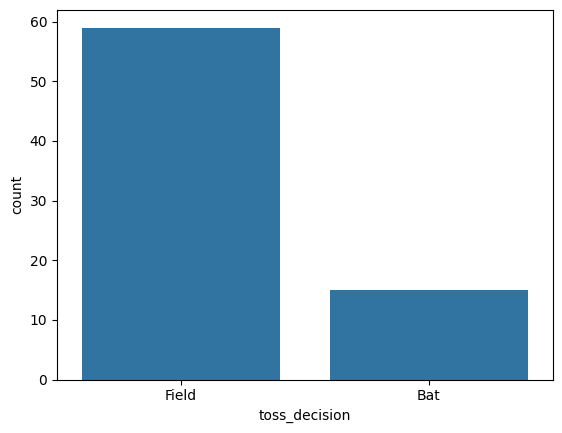

In [40]:
sns.countplot(x = data['toss_decision'])

##  Does Toss winner is a  Match winner

In [41]:
count = data[data['toss_winner'] == data['match_winner']]['match_id'].count()
percent = (count * 100)/data.shape[0]
percent.round(2)
# 48.65% of team win toss but not the match


np.float64(48.65)

## How do teams win? (Runs or Wickets)

In [42]:
Teams_win_by = data.won_by.value_counts()
Teams_win_by

,count
won_by,
Wickets,37
Runs,37


<Axes: xlabel='won_by', ylabel='count'>

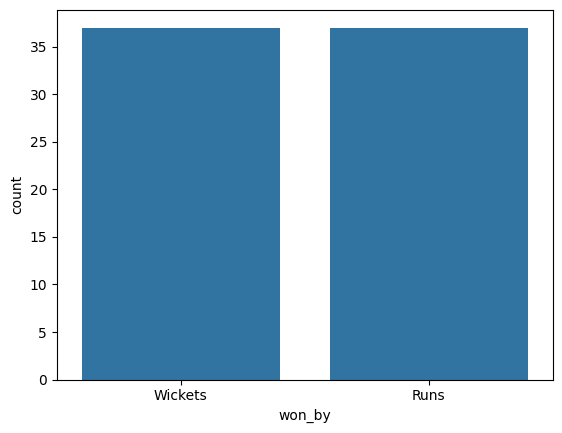

In [43]:
sns.countplot(x = data['won_by'])

##Toss won by each team

In [44]:
Toss_won_data = data['toss_winner'].value_counts()
Toss_won_data

,count
toss_winner,
Hyderabad,10
Gujarat,10
Mumbai,9
Kolkata,8
Delhi,8
Banglore,8
Lucknow,7
Chennai,6
Punjab,4


<Axes: ylabel='toss_winner'>

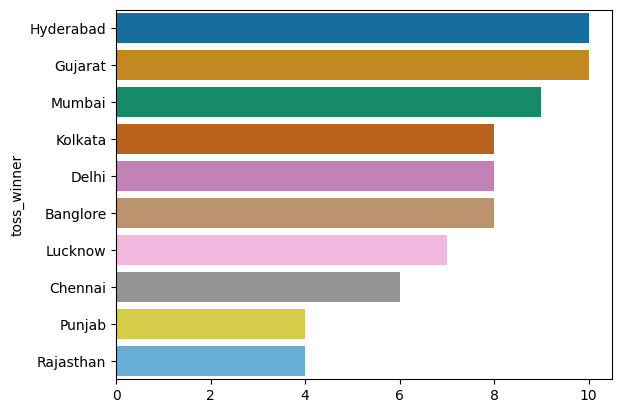

In [45]:
sns.barplot(y = Toss_won_data.index,x = Toss_won_data.values,palette='colorblind')

## Most player of the match award

In [46]:
Highest_player_of_the_match = data['player_of_the_match'].value_counts().head(10)
Highest_player_of_the_match


,count
player_of_the_match,
Kuldeep Yadav,4
Jos Buttler,3
Wanindu Hasaranga,2
Umesh Yadav,2
Quinton de Kock,2
Shubman Gill,2
Avesh Khan,2
Dinesh Karthik,2
Hardik Pandya,2


<Axes: ylabel='player_of_the_match'>

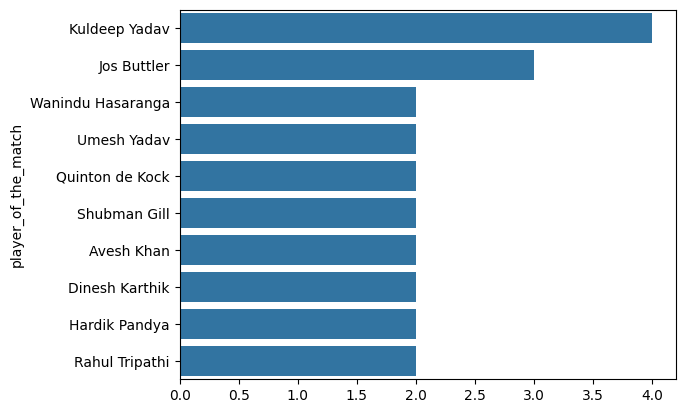

In [47]:
sns.barplot(y = Highest_player_of_the_match.index,x = Highest_player_of_the_match.values)


## Top Scorers

In [48]:
high = data.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high


,highscore
top_scorer,
Jos Buttler,651
Quinton de Kock,377


<Axes: ylabel='top_scorer'>

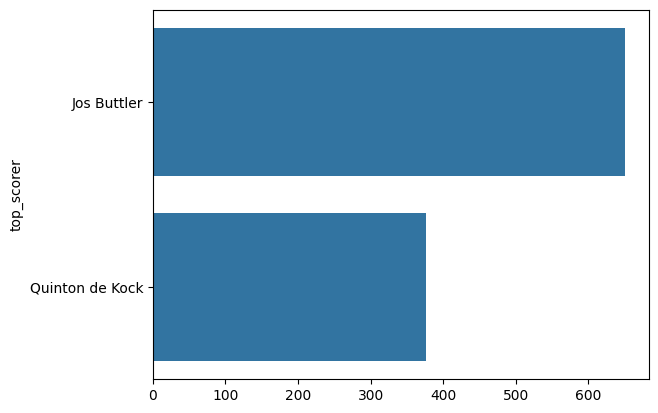

In [49]:
sns.barplot(y = high.index,x = high.values)

## Best Bowling Figures

In [50]:
data['highest_wickets'] = data['best_bowling_figure'].apply(lambda x: x.split('--')[0])
data['highest_wickets'] = data['highest_wickets'].astype('int')
top_bowler = data.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(5)


<Axes: ylabel='best_bowling'>

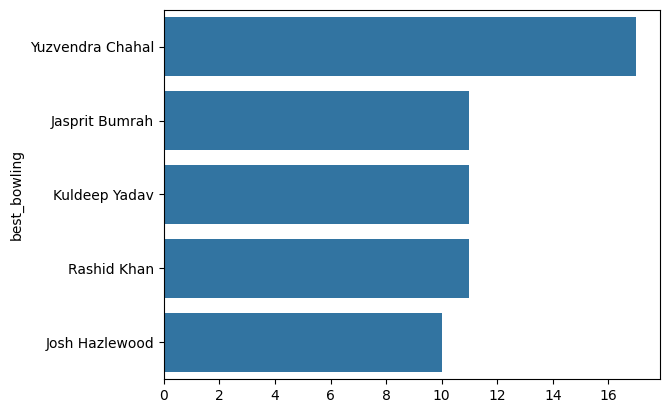

In [51]:
sns.barplot(y = top_bowler.index, x = top_bowler.values)

## Most matches played by venue

In [52]:
venue_count = data['venue'].value_counts()
venue_count

,count
venue,
"Wankhede Stadium, Mumbai",21
"Dr DY Patil Sports Academy, Mumbai",20
"Brabourne Stadium, Mumbai",16
"Maharashtra Cricket Association Stadium,Pune",13
"Eden Gardens, Kolkata",2
"Narendra Modi Stadium, Ahmedabad",2


<Axes: ylabel='venue'>

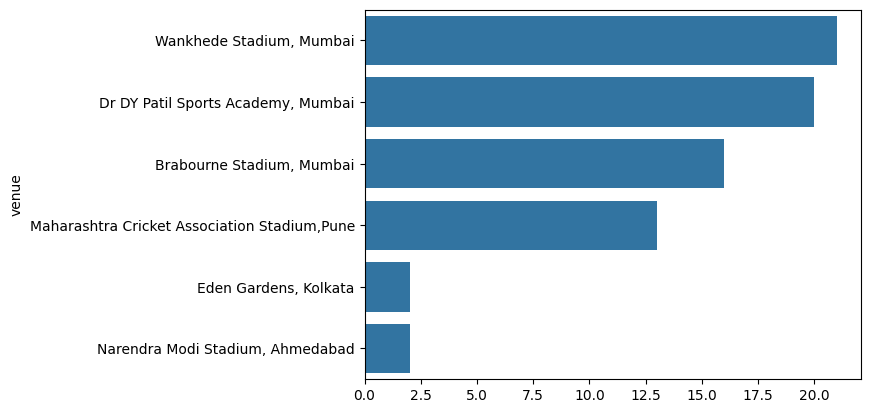

In [53]:
sns.barplot(y = venue_count.index,x = venue_count.values)